#1)Problem Statement:
The goal of this project is to predict the strength of concrete using machine learning.

The dataset used in this project is the Concrete dataset, which contains the columns Cement, Blast Furnace Slag, Fly Ash, Water, Superplasticizer, Coarse Aggregate, Fine Aggregate, Age, and Strength.

The Strength column is the target variable, and the remaining columns are used as input features. This is a regression problem because the target variable is a continuous value.

A Sequential Artificial Neural Network (ANN) model is built to train the data and predict the strength of concrete based on the given features.

#2)Import Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler

In [3]:
import tensorflow as tf

In [4]:
from tensorflow.keras.models import Sequential

#3)Load Dataset:

In [5]:
df=pd.read_csv("/content/concrete_data.csv")

In [6]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


#4)Handling Missing Values(NaNs):

In [7]:
df.isna().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


#5)Remove Error/Data Cleaning:

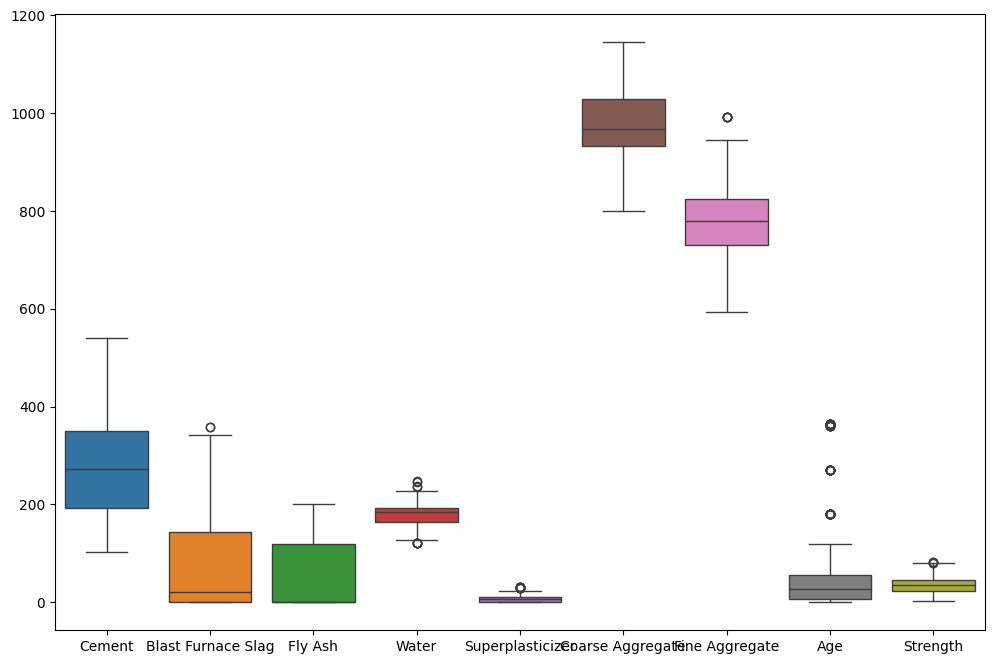

In [8]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.show()

In [9]:
df.columns

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

In [10]:
df["Age"].max()

365

In [11]:
df["Age"].min()

1

In [12]:
cols=['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [13]:
cols

['Blast Furnace Slag', 'Water', 'Superplasticizer', 'Fine Aggregate']

In [14]:
for c in cols:
  print(c)

Blast Furnace Slag
Water
Superplasticizer
Fine Aggregate


In [15]:
for c in cols:
  q1=df[c].quantile(0.25)
  q3=df[c].quantile(0.75)
  iqr=q3-q1
  lower=q1-(1.5*iqr)
  upper=q3+(1.5+iqr)
  df[c]=df[c].map(lambda x:lower if x<lower else upper if x>upper else x)

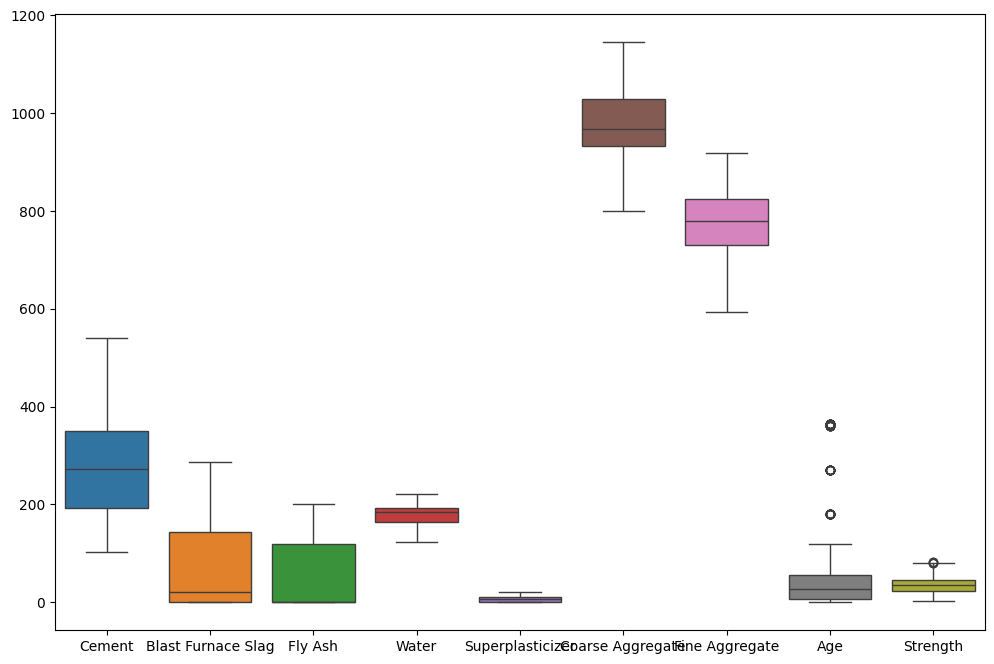

In [16]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.show()

In [17]:
df["Age"]

,Age
0,28
1,28
2,270
3,365
4,360
...,...
1025,28
1026,28
1027,28
1028,28


In [18]:
q1_age=df["Age"].quantile(0.25)
q3_age=df["Age"].quantile(0.75)
iqr_age=q3_age-q1_age
lower_age=q1_age-(1.5*iqr_age)
upper_age=q3_age+(1.5*iqr_age)

In [19]:
lower_age

np.float64(-66.5)

In [20]:
upper_age

np.float64(129.5)

In [21]:
df[df["Age"]<lower_age ]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength


In [22]:
df[df["Age"]>upper_age ]

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
2,332.5,142.5,0.0,220.6,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,220.6,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
6,380.0,95.0,0.0,220.6,0.0,932.0,594.0,365,43.70
12,427.5,47.5,0.0,220.6,0.0,932.0,594.0,270,43.01
17,342.0,38.0,0.0,220.6,0.0,932.0,670.0,365,56.14
19,475.0,0.0,0.0,220.6,0.0,932.0,594.0,180,42.62
20,427.5,47.5,0.0,220.6,0.0,932.0,594.0,180,41.84
23,139.6,209.4,0.0,192.0,0.0,1047.0,806.9,180,44.21
24,380.0,0.0,0.0,220.6,0.0,932.0,670.0,365,52.52


In [25]:
len(df[df["Age"]>upper_age ])

59

In [26]:
df[df["Age"]>upper_age ].count()

,0
Cement,59
Blast Furnace Slag,59
Fly Ash,59
Water,59
Superplasticizer,59
Coarse Aggregate,59
Fine Aggregate,59
Age,59
Strength,59


In [27]:
df["Age"]=df["Age"].map(lambda x:lower_age if x<lower_age else upper_age if x>upper_age else x)

<Axes: ylabel='Age'>

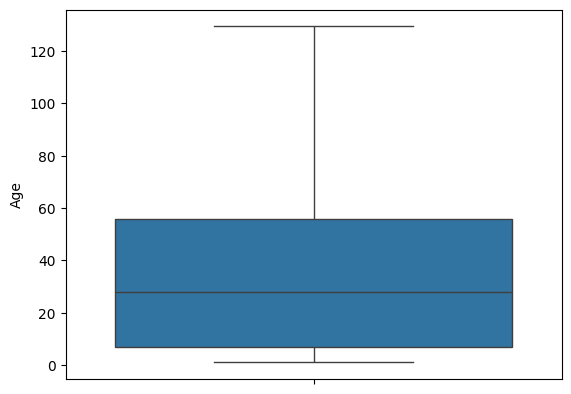

In [28]:
sns.boxplot(df["Age"])

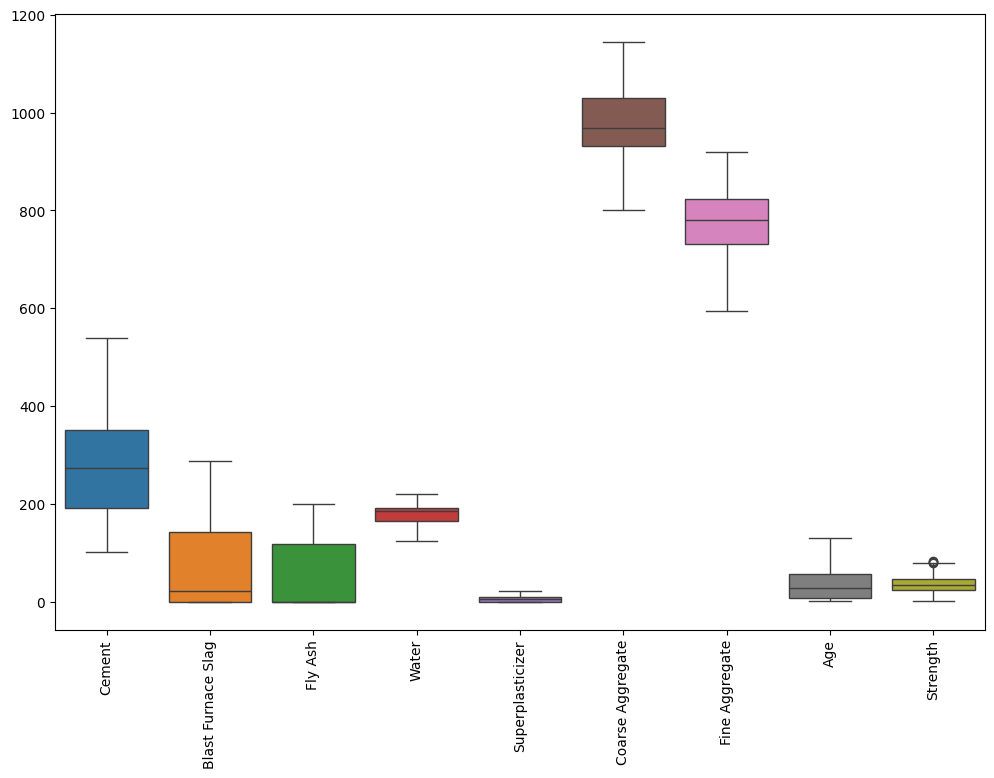

In [29]:
plt.figure(figsize=(12,8))
sns.boxplot(df)
plt.xticks(rotation=90)
plt.show()

#6)Data Seperation:

In [30]:
df

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28.0,61.89
2,332.5,142.5,0.0,220.6,0.0,932.0,594.0,129.5,40.27
3,332.5,142.5,0.0,220.6,0.0,932.0,594.0,129.5,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,129.5,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28.0,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28.0,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28.0,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28.0,32.77


In [31]:
x=df.drop("Strength",axis=1)

In [32]:
y=df["Strength"]

#7)Data Spliting:

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,random_state=42)

In [36]:
x.shape

(1030, 8)

In [37]:
x_train.shape

(824, 8)

In [38]:
x_test.shape

(206, 8)

#8)Feature Scaling:

In [39]:
from sklearn.preprocessing import StandardScaler

In [43]:
ss=StandardScaler()

In [44]:
ss

StandardScaler()

In [45]:
x_train_ss=ss.fit_transform(x_train)

In [46]:
x_test_ss=ss.transform(x_test)

In [47]:
x_train_ss

array([[-1.16087734,  0.87250578,  0.9824489 , ..., -0.25746155,
        -0.65086717, -0.27964442],
       [ 1.30862304, -0.60546721,  1.23259821, ..., -1.92694961,
        -0.26952933, -0.27964442],
       [-0.0768653 , -0.86169578,  1.06687429, ...,  1.01785948,
         0.07656937, -0.98804026],
       ...,
       [-0.86591441, -0.86169578,  1.12628475, ...,  1.34082214,
         0.34589709,  1.76053561],
       [ 1.78316909,  0.52193851, -0.83113361, ..., -1.54422615,
         0.126911  , -0.27964442],
       [ 0.28509237, -0.86169578,  0.9355459 , ..., -0.6172979 ,
         0.14578911, -0.27964442]])

In [48]:
x_test_ss

array([[-0.1615392 ,  0.46603409, -0.83113361, ..., -0.52829244,
        -1.27636192,  2.59644271],
       [ 0.73730683,  1.33954059, -0.83113361, ..., -0.36681111,
        -0.19653397, -0.87469693],
       [ 0.99132853,  1.33954059, -0.83113361, ..., -0.36681111,
        -0.19653397, -0.27964442],
       ...,
       [ 0.02734873,  1.47813695, -0.83113361, ...,  0.39482129,
         0.40630705, -0.87469693],
       [ 1.30862304, -0.60546721,  1.23259821, ..., -1.92694961,
        -0.26952933,  0.51375893],
       [ 0.51771297, -0.86169578, -0.83113361, ..., -0.07055009,
         0.1206183 ,  1.47717727]])

In [49]:
x_train.shape

(824, 8)

In [50]:
x_train.shape[1]

8

#9)Model Building:

In [51]:
from tensorflow.keras.models import Sequential

In [52]:
from tensorflow.keras.layers import Dense

In [53]:
smodel=Sequential()

In [54]:
smodel.add(Dense(64, activation="relu", input_shape=(x_train.shape[1],)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [55]:
smodel.add(Dense(32,activation="relu"))

In [56]:
smodel.add(Dense(1))

In [57]:
smodel.compile(optimizer="adam",
               loss="mean_squared_error")

In [58]:
smodel.fit(x_train_ss,y_train,epochs=30,validation_split=0.2,verbose=0)

In [59]:
smodel.evaluate(x_test_ss,y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 97.5804  


97.31269836425781

In [60]:
np.sqrt(96.5978)

np.float64(9.828417980529725)

#Conclusion:
In this project, the Concrete dataset was used to predict the strength of concrete using an Artificial Neural Network model. Data preprocessing steps such as removing missing values, fixing errors, and scaling the features were performed.

A Sequential ANN model was trained on the dataset and evaluated using the test data. The model achieved an accuracy score of about 97%, which shows that the model performs well in predicting the strength of concrete.

This project demonstrates how neural networks can be used to solve regression problems and make predictions based on multiple input features.